In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import(
    RandomForestRegressor,
    GradientBoostingRegressor,
    AdaBoostRegressor,
    BaggingRegressor,
    VotingRegressor,
    StackingRegressor)
from sklearn.neighbors import KNeighborsRegressor, NearestNeighbors

In [47]:
### outcome variable is sepal length
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
X = df[['sepal width (cm)', 'petal length (cm)', 'petal width (cm)']]
y = df['sepal length (cm)']

### 75/25 train/test split
X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    test_size=0.25, 
                                                    random_state=42)

In [48]:
def compute_metrics(name, y_test, y_preds):
    MSE = mean_squared_error(y_test, y_preds)
    RMSE = np.sqrt(MSE)
    R2 = r2_score(y_test, y_preds)

    return {
        'Model': name,
        'MSE': MSE,
        'RMSE': RMSE,
        'R2': R2
    }

In [49]:
models = {
    'Linear Regression': LinearRegression(),
    
    'Lasso': Lasso(),
    
    'KNN-1': KNeighborsRegressor(n_neighbors=1),
    
    'KNN-3': KNeighborsRegressor(n_neighbors=3),
    
    'KNN-5': KNeighborsRegressor(n_neighbors=5),
    
    'Decision Tree': DecisionTreeRegressor(max_depth=5, random_state=42),
    
    'Voting': VotingRegressor([
        ('linreg', LinearRegression()),
        ('lasso', Lasso()),
        ('knn1', KNeighborsRegressor(n_neighbors=1)),
        ('knn3', KNeighborsRegressor(n_neighbors=3)),
        ('knn5', KNeighborsRegressor(n_neighbors=5)),
        ('dt', DecisionTreeRegressor(max_depth=5, random_state=42))]),
    
    'Bagging': BaggingRegressor(
        estimator=DecisionTreeRegressor(max_depth=5, random_state=42),
        n_estimators=100,
        bootstrap=True,
        random_state=42),
    
    'Random Forest': RandomForestRegressor(
        n_estimators=100,
        max_depth=5,
        random_state=42),
    
    'Stacking': StackingRegressor([
        ('linreg', LinearRegression()),
        ('lasso', Lasso()),
        ('knn1', KNeighborsRegressor(n_neighbors=1)),
        ('knn3', KNeighborsRegressor(n_neighbors=3)),
        ('knn5', KNeighborsRegressor(n_neighbors=5)),
        ('dt', DecisionTreeRegressor(max_depth=5, random_state=42))])
}

In [50]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    metrics = compute_metrics(name, y_test, y_pred)
    results.append(metrics)

results_df = pd.DataFrame(results).sort_values('RMSE').reset_index(drop=True).round(3)
results_df

,Model,MSE,RMSE,R2
0,Stacking,0.084,0.290,0.885
1,Random Forest,0.101,0.317,0.861
2,Linear Regression,0.101,0.317,0.861
3,Bagging,0.103,0.321,0.858
4,KNN-5,0.109,0.330,0.850
5,Voting,0.110,0.332,0.849
6,KNN-3,0.142,0.377,0.805
7,Decision Tree,0.153,0.391,0.790
8,KNN-1,0.176,0.420,0.758
9,Lasso,0.545,0.738,0.251


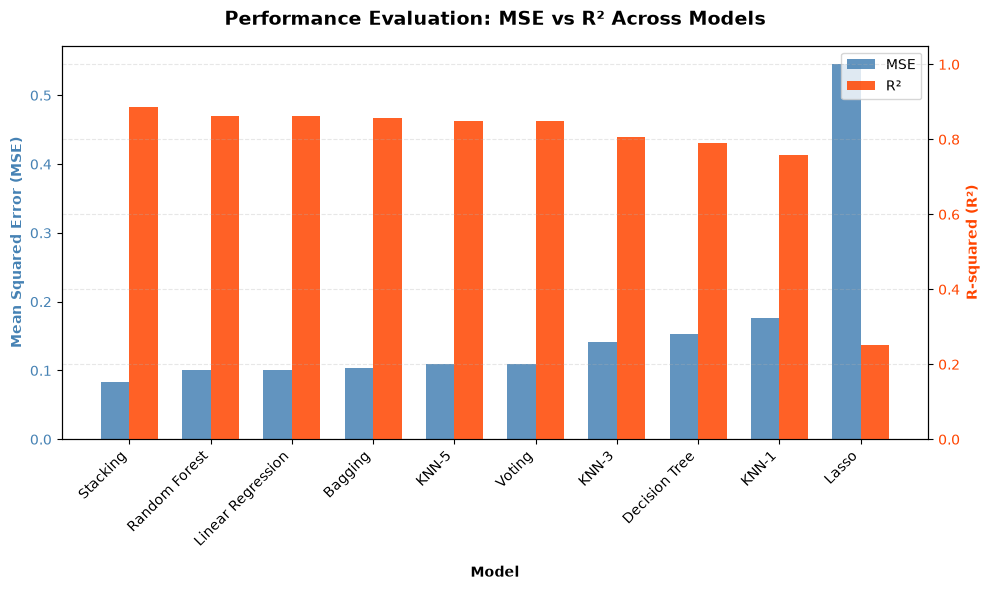

In [51]:
### set up positions for the grouped bars
x = np.arange(len(results_df["Model"]))
width = 0.35  # Individual bar width

fig, ax1 = plt.subplots(figsize=(10, 6))

### left y-axis: MSE bars
mse_color = "steelblue"
ax1.set_xlabel("Model", fontweight="bold", labelpad=12)
ax1.set_ylabel("Mean Squared Error (MSE)", color=mse_color, fontweight="bold")
bar1 = ax1.bar(x - width / 2, results_df["MSE"], width, label="MSE", color=mse_color, alpha=0.85)
ax1.tick_params(axis="y", labelcolor=mse_color)
ax1.set_xticks(x)
ax1.set_xticklabels(results_df["Model"], rotation=45, ha="right")

### right y-axis: R-squared bars
ax2 = ax1.twinx()
r2_color='orangered'
ax2.set_ylabel("R-squared (R²)", color=r2_color, fontweight="bold")
bar2 = ax2.bar(x + width / 2, results_df["R2"], width, label="R²", color=r2_color, alpha=0.85)
ax2.tick_params(axis="y", labelcolor=r2_color)
ax2.set_ylim(0, 1.05)

### legend
bars = [bar1, bar2]
labels = [b.get_label() for b in bars]
ax1.legend(bars, labels, loc="upper right")
plt.title("Performance Evaluation: MSE vs R² Across Models",
          fontsize=14, 
          fontweight="bold", pad=15)

plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()

plt.show()